# TP2 - Text Retrieval - Binary Independence Retrieval & Latent Semantic Indexing  (10/03/2025)

## 1. Goal

<font size="3">
In this exercise, we introduce two other basic models in information retrieval namely, the <b><i>probabilistic</i></b> and <b><i>latent semantic indexing models</i></b>. The given tasks should help you understand better how to find a discriminative set of <b><i>index terms</i></b> (keywords) for a collection of documents and queries. To summarize the content of each document, we first apply the <b><i>Porter algorithm</i></b> and then extract the most informative words from documents based on the <b><i>term frequency-inverse documents frequency</i></b> (tf-idf) weighting scheme. Finally, we implement the <b><i>probabilistic</i></b> and <b><i>latent semantic indexing models</i></b> to predict which documents are relevant to a particular query.
</font>

## 2. Introduction

### 2.1 Probabilistic model

<font size="3">

The <b><i>probabilistic model</i></b> is a simple retrieval model based on a probabilistic framework. It considers a user query and a set of documents that contains only relevant documents for this query. This set can be viewed as the ideal answer set. If the descriptors/properties/characteristics of this ideal answer set were known, retrieving its documents would be easier. However, these properties are usually not known and will be specified during the quering process. We only know that there are index terms whose semantic characteristics should be used to describe these properties. Initially, these properties are not known for a particular query. We attempt to guess what they could be, so that these initial values serve as a preliminary probabilistic description of the ideal answer set.
    
We assume that there is a given user query $q$ and a document $d_{j}$ in the data base. We attempt to estimate the probability that the user will find the document $d_{j}$ as interesting. The fundamental assumption is that this probability of relevance depends only on the query and the document representations. Moreover, there is an ideal subset of all the documents, which the user chooses as the answer for this query.
    
In the <b><i>probabilistic model</i></b>, the index term weight variables are binary. A query $q$ is a subset of index terms. Let $R$ be the set of documents initially guessed to be relevant. Let $\bar{R}$ be the complement set of R, which means the set of all non-relevant documents in the collection. Let $P(R|d_{j})$ be the probability that the document $d_{j}$ is relevant to the query $q$ and $P(\bar{R}|d_{j})$ be the probability that the document $d_{j}$ is non-relevant to the query $q$. The similarity measure $sim(d_{j},q)$ between the document $d_{j}$ and the query $q$ is defined as the ratio
\begin{equation}
sim(d_{j},q)= \frac{P(R|d_{j})}{P(\bar{R}|d_{j})}.
\end{equation}
    
Applying <b><i>Bayes' rule</i></b>, we get the following expression
\begin{equation}
sim(d_{j},q)= \frac{P(d_{j}|R)\cdot P(R)}{P(d_{j}|\bar{R})\cdot P(\bar{R})},
\end{equation}
    
where $P(d_{j}|R)$ corresponds to the probability of randomly selecting the document $d_{j}$ from the set $R$ and $P(R)$ corresponds to the probability that a selected document is relevant. Likewise, $P(d_{j}|\bar{R})$ and $P(\bar{R})$ are the analogous probabilities for the complementary set of non-relevant documents.
    
Assuming independence of <b><i>index terms</i></b> and taking logarithms, we can finally write:
    
\begin{equation}
sim(d_{j},q)=\sum_{i=1}^{k} w_{iq} \cdot w_{ij} \cdot \left( \log \frac{P(t_{i}|R)}{1-P(t_{i}|R)} +\log \frac{1-P(t_{i}|\bar{R})}{P(t_{i}|\bar{R})} \right),
\end{equation}
    
where  $P(t_{i}|R)$ corresponds to the probability that the <b><i>index term</i></b> $t_{i}$ is present in a document, randomly selected from the set $R$. The probabilities associated with the set $\bar{R}$ have meanings that are analogous to the ones just described.
    
Since we do not know the set $R$ at the beginning, it is necessary to choose a method for initially  computing the probabilities $P(t_{i}|R)$ and $P(t_{i}|\bar{R})$. We discuss an approach to compute them.
    
We initially assume that $P(t_{i}|R)$ is constant for all index terms, e.g. equal $0.5$. Furthermore, we approximate the distribution of <b><i>index terms</i></b> among non-relevant documents by the distribution of index terms across all documents in the collection. These two assumptions lead to the following:

\begin{equation}
P(t_{i}|R)=0.5, P(t_{i}|\bar{R})=\frac{n_{i}}{N},
\end{equation}
    
where $N$ is the total number of documents, and $n_{i}$ is the number of documents in which the
term $t_{i}$ appears. Based on this, we retrieve an initial probabilistic <b><i>ranking</i></b> that is iteratively improved as it follows.
    
Let $V$ be a subset of the documents initially retrieved and ranked by the probabilistic model, for instance, the top $r$ ranked documents where $r$ is a certain <b><i>threshold</i></b>. Moreover, let $V_{i}$ be the subset of $V$ composed of the documents in $V$ which contain the <b><i>index term</i></b> $t_{i}$.
    
We iteratively improve the initially guessed values of $P(t_{i}|R)$ and $P(t_{i}|\bar{R})$. This is achieved by satisfying the following assumptions: we approximate $P(t_{i}|R)$ by the distribution of index term $t_{i}$ among the documents retrieved so far, and we approximate $P(t_{i}|\bar{R})$ by considering that all the non-retrieved documents are not relevant. Based on these assumptions, we express the updating rules as follows:
    
\begin{equation}
P(t_{i}|R):=\frac{|V_{i}|}{|V|}, P(t_{i}|\bar{R}):=\frac{n_{i}-|V_{i}|}{N-|V|}.
\end{equation}
    
The last formulas for $P(t_{i}|R)$ and $P(t_{i}|\bar{R})$ have a problem for small values of $V$ and $V_{i}$ that appear in practice. To solve it, we add an adjustment factor and obtain:
    
\begin{equation}
P(t_{i}|R):=\frac{|V_{i}|+0.5}{|V|+1}, P(t_{i}|\bar{R}):=\frac{n_{i}-|V_{i|}+0.5}{N-|V|+1}.
\end{equation}
    
An alternative is to take the fraction $\frac{n_{i}}{N}$ as the adjustment factor and get:

\begin{equation}
P(t_{i}|R):=\frac{|V_{i}|+\frac{n_{i}}{N}}{|V|+1},  P(t_{i}|\bar{R}):=\frac{n_{i}-|V_{i}|+\frac{n_{i}}{N}}{N-|V|+1},
\end{equation}
    
where $|\cdot|$ means a number of set elements.
</font>

### 2.2 Latent semantic indexing model

<font size="3">
    
The <b><i>Latent Semantic Indexing (LSI) model</i></b> matches documents to a given query based on conceptual similarity rather than matching exact index terms. In this way, it retrieves relevant documents even when they are not explicitly indexed by query terms. For example, a document might be retrieved because it shares concepts with another document, which is relevant to the given query. <b><i>LSI</i></b> maps each document and query vector into a lower dimensional space, which is associated with concepts. The reduced space might be better for information retrieval compared to the original one.
    
Let $k$ be the number of index terms in the collection of documents and $N$ be the the total number of documents. Define $M$ as a matrix with $k$ rows and $N$ columns. Each element $M_{ij}$ of this matrix is assigned a weight $w_{ij}$ associated with the index term $t_{i}$ and the document $d_{j}$. The weight $w_{ij}$ could be generated using the <b><i>tf-idf </i></b> weighting scheme.

<b><i>LSI</i></b> decomposes the <b><i>term-document</i></b> matrix $M$ using the <b><i>singular value decomposition</i></b> as it follows:
    
\begin{equation}
M=S \cdot  \Delta \cdot D^{T}.
\end{equation}
    
Matrix $S$ is the matrix of eigenvectors obtained from $M\cdot M^{T}$. Matrix $D$ is the matrix of eigenvectors derived from $ M^{T} \cdot M$. Matrix $ \Delta$ is an $r \times r$ diagonal matrix of singular values where $r=min(k,N)$ is the rank of $M$.
    
Consider now only the $l$ largest singular values of $ \Delta$ and keep them along with their corresponding columns in $S$ and $D$, respectively. The result is matrix $M_{l}$ given by:
    
\begin{equation}
M_{l}=S_{l} \cdot  \Delta_{l} \cdot D_{l}^{T},
\end{equation}
    
where $l$, $l<r$, is the dimensionality of the reduced concept space. The selection of a value for $l$ tries to balance two opposing effects. It means that $l$ should be large enough to capture all the structure presente in the real data. On the other hand, it should be small enough to filter out non-relevant details of data.
    
The relation between any two documents in the reduced space of dimensionality $l$ can be derived from the matrix $M_{l}^{T} \cdot M_{l}$, where the element $(i,j)$ quantifies the relationship between documents  $d_{i}$ and  $d_{j}$.
    
To rank the documents with regards to a given user query, we consider the query as a document in the original matrix $M$, and map it into the same reduced-dimensional space as the documents.
    
</font>

## 3. List of tasks

<font size="3">
For tasks 1-3 you can reuse the TP1 code given that all models use the same weighting scheme (except for the Boolean).
    
<ol>
    <li>Use 15 articles from the NASA corpus to obtain raw data and apply <i>tokenisation</i>.</li>
    <li> Perform <i>stemming</i> using the <i>Porter algorithm</i>. </li>
    <li> Compute the <i>term frequency </i>$tf_{ij}$ and <i>tf-idf</i> $w_{ij}$ for each document with and without removing stop words.</li>
    <li> Build the <i>probabilistic</i> and <i>latent semantic indexing models</i> based on top $p$ stems according to <i>tf-idf</i> for each document, without removing stop words, and then provide $s$ queries to each IR system. Compare the rankings of the relevant articles for the two models.</li>
    <li>Remove the stop words and provide again the same queries to each IR model. Compare the current rankings of relevant articles with the ones obtained before.</li>
    <li>Compare the <i>BIR</i> and <i>LSI</i> results with the results from the <i>boolean</i> and <i>vector models</i> in TP1 (with stop words removal).
    <li>Give some final remarks and conclusions.</li>
</ol>
    
</font>

## 4. Practical requirements

### 4.1 Implementation of required functions

<font size="3">
    
<li>Create a class <b>ProbModelIR</b> that is initialized with parameters <b> (root_docs_path, num_docs=15, p=50, remove_stop_words=False) </b> and implements the functions :</li>
    <ul>
        <li><b>termDocumentMatrixProbModel(self)</b>: reads all <i>.txt</i> from a specifed directory (where your corpus is), creates a boolean representation for each document, and puts them together into a term-document matrix.</li>
        <li><b>queryBooleanRepresentationProbModel(queries)</b>: returns a boolean representation of a query for the probabilistic model.</li>
        <li><b>rankingProbModel(self,...)</b>: computes the similarity between a given query and the documents, and returns similarity values and filenames of the top $N$ relevant documents.</li>
    </ul>
    
<li>Create a class <b>LSIModelIR</b> that is initialized with parameters <b> (root_docs_path, num_docs=15, p=50, remove_stop_words=False) </b> and implements the functions :</li>
    <ul>
        <li><b>termDocumentMatrixLatentSemanticIndexing(self)</b>: reads all <i>.txt</i> from a specifed directory (where your corpus is), creates a latent semantic indexing representation for all documents and queries, and puts them together into a term-document matrix.</li>
        <li><b>queryVectorRepresentationLSIModel(queries)</b>: returns a vector representation of a query for the latent semantic indexing model.</li>
        <li><b>rankingLatentSemanticIndexing(self,...)</b>: computes the similarity between a given query and the documents, and returns similarity values and filenames of the top $N$ relevant documents. Note that a query is treated as a short document in term-document matrix.</li>
    </ul>

</font>

### 4.2 Required evaluation corpus

<font size="3">

<b>NASA</b> collection covers 141 short articles in <b>nasa.tar.gz</b> file.

</font>

## 5. Assessment

### 5.1 Content

<font size="3">

The assessment is based on your notebook. Your report should be submitted as a single `.ipynb` (notebook) file, following the requirements of a scientific report, including:
<ul>
    <li>a reminder of the problem to solve
    <li>a mathematical description of your solution
    <li>references when appropriate
 </ul>
  
Your notebook should include your code, results, detailed answers to all questions, and conclusions.

</font>

### 5.2 Deadline

<font size="3">
    
Please save your notebook as "TP2_NameSurname.ipynb" and upload it to <a href="http://moodle.unige.ch" target="_blank">Moodle</a> in the section <b>Submissions 2025</b> under TP2 before Sunday, March 23, 2025, 23:59.
Later submissions will not be accepted.
    
</font>

In [1]:
# Imports
from google.colab import drive

import os
import tarfile
from collections import Counter
from itertools import count


import nltk
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

import numpy as np
import pandas as pd


from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import Binarizer


import matplotlib.pyplot as plt
from wordcloud import WordCloud


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


### File I/O

In [3]:
path_to_file = os.path.join("/content/drive/MyDrive/nasa", "nasa.tar.gz")  # Updated path
path_to_extract = os.path.join("nasa")

with tarfile.open(path_to_file, 'r:gz') as tar:
    tar.extractall(path_to_extract)

In [4]:
root_docs_path = os.path.join("nasa")

# find all files that ends with .txt in the given directory and store them in a list
documents = [file for file in os.listdir(root_docs_path) if file.endswith('txt')]

# number of documents to consider, e.g.,
num_docs = 15
documents = documents[:num_docs]

# map documents to indices
# make a dictionary where keys are document names and values are their indices
doc2id = documents
id2doc = {doc:idx for idx, doc in enumerate(doc2id)}
id2doc

{'inf14495.txt': 0,
 'inf17395.txt': 1,
 'str01895.txt': 2,
 'sbr12195.txt': 3,
 'inf18595.txt': 4,
 'str03295.txt': 5,
 'eos19895.txt': 6,
 'sbr19195.txt': 7,
 'str12695.txt': 8,
 'mat18195.txt': 9,
 'inf19695.txt': 10,
 'sbr17995.txt': 11,
 'inf17195.txt': 12,
 'emt04795.txt': 13,
 'mip14795.txt': 14}

In [5]:
# print("total documents:", len(documents))

# # acess the id of a document as id2doc["filename"]
# print(id2doc['ins16295.txt'])

# # access the i-th document as doc2id[i]
# print(doc2id[5])

In [6]:
# store the raw text data in a list
# f.readlines(): each line in the file is a list item

docs_text_raw = [None]*len(documents)

for num_file, file in enumerate(documents):
    with open(os.path.join(root_docs_path, file), mode='r', encoding='windows-1252') as f:
        docs_text_raw[num_file] = f.readlines()

In [7]:
docs_text_raw[0]

[' \n',
 '\n',
 'Surface Navigation in Low Visibility Conditions\n',
 '\n',
 'NASA and industry are developing new automated technologies\n',
 '\n',
 'NASA and industry are developing new automated technologies to improve\n',
 'safety and increase capacity of the airport surface movement area during low\n',
 'visibility conditions. As part of this joint effort, an electronic moving\n',
 'map display has been integrated with a surface radar system and a high speed\n',
 'data link. By sending controller information and air traffic positions to\n',
 'aircraft by a digital data link, pilots will be more aware of the airport\n',
 'environment in all weather conditions.\n',
 '\n',
 ' \n',
 'Schematic of ASTA flight concept\n',
 '\n',
 'Potential Commercial Uses\n',
 '\n',
 '   * Any navigation systems, including:\n',
 '        o Automotive\n',
 '        o Rail\n',
 '        o Ships\n',
 '        o Aircraft\n',
 '        o Police, fire, ambulance\n',
 '\n',
 'Benefits\n',
 '\n',
 '   * Improv

### 1. Use 15 articles from the NASA corpus to obtain raw data and apply tokenisation.

In [8]:
def clean_raw_text(docs):

    punctuations=r'''!()-[]{};:'"\,<>./?@#$%^&*_~'''
    digits = '0123456789'

    for doc_num, doc in enumerate(docs):
        # doc is a list of sentences
        for sent_num, sent in enumerate(doc):
            # lowercase
            sent = sent.lower()

            # removing the punctuations and numbers
            sent = "".join([char for char in sent if char not in punctuations + digits])

            docs[doc_num][sent_num] = sent

    return docs

In [9]:
stop_words = set(stopwords.words('english'))

def tokenize_docs(docs):

    docs = clean_raw_text(docs)
    docs_tokenized = []

    for doc_num, doc in enumerate(docs):

        docs_tokenized.append([nltk.word_tokenize(line) for line in doc])

    return docs_tokenized

In [10]:
docs_text_tokenized = tokenize_docs(docs_text_raw)

### 2. Perform stemming using the Porter algorithm.

In [11]:
def flatten(doc):
    # doc is a list of lists
    # convert into a single flat list (collapse all sentences of the doc into one)
    # check if sentences are empty because of preprocessing/tokenization
    return [word for sentence in doc for word in sentence if len(sentence) > 0]

In [12]:
docs_text_tokenized = [flatten(doc) for doc in docs_text_tokenized]

In [13]:
docs_text_tokenized[0]

['surface',
 'navigation',
 'in',
 'low',
 'visibility',
 'conditions',
 'nasa',
 'and',
 'industry',
 'are',
 'developing',
 'new',
 'automated',
 'technologies',
 'nasa',
 'and',
 'industry',
 'are',
 'developing',
 'new',
 'automated',
 'technologies',
 'to',
 'improve',
 'safety',
 'and',
 'increase',
 'capacity',
 'of',
 'the',
 'airport',
 'surface',
 'movement',
 'area',
 'during',
 'low',
 'visibility',
 'conditions',
 'as',
 'part',
 'of',
 'this',
 'joint',
 'effort',
 'an',
 'electronic',
 'moving',
 'map',
 'display',
 'has',
 'been',
 'integrated',
 'with',
 'a',
 'surface',
 'radar',
 'system',
 'and',
 'a',
 'high',
 'speed',
 'data',
 'link',
 'by',
 'sending',
 'controller',
 'information',
 'and',
 'air',
 'traffic',
 'positions',
 'to',
 'aircraft',
 'by',
 'a',
 'digital',
 'data',
 'link',
 'pilots',
 'will',
 'be',
 'more',
 'aware',
 'of',
 'the',
 'airport',
 'environment',
 'in',
 'all',
 'weather',
 'conditions',
 'schematic',
 'of',
 'asta',
 'flight',
 'conc

In [14]:
def stem(docs):

    ps = PorterStemmer()
    docs_stemmed = []

    for doc in docs:
        # stemmer takes a string as input
        docs_stemmed.append([ps.stem(word) for word in doc])

    return docs_stemmed

In [15]:
docs_text_stemmed = stem(docs_text_tokenized)

In [16]:
docs_text_stemmed[0]

['surfac',
 'navig',
 'in',
 'low',
 'visibl',
 'condit',
 'nasa',
 'and',
 'industri',
 'are',
 'develop',
 'new',
 'autom',
 'technolog',
 'nasa',
 'and',
 'industri',
 'are',
 'develop',
 'new',
 'autom',
 'technolog',
 'to',
 'improv',
 'safeti',
 'and',
 'increas',
 'capac',
 'of',
 'the',
 'airport',
 'surfac',
 'movement',
 'area',
 'dure',
 'low',
 'visibl',
 'condit',
 'as',
 'part',
 'of',
 'thi',
 'joint',
 'effort',
 'an',
 'electron',
 'move',
 'map',
 'display',
 'ha',
 'been',
 'integr',
 'with',
 'a',
 'surfac',
 'radar',
 'system',
 'and',
 'a',
 'high',
 'speed',
 'data',
 'link',
 'by',
 'send',
 'control',
 'inform',
 'and',
 'air',
 'traffic',
 'posit',
 'to',
 'aircraft',
 'by',
 'a',
 'digit',
 'data',
 'link',
 'pilot',
 'will',
 'be',
 'more',
 'awar',
 'of',
 'the',
 'airport',
 'environ',
 'in',
 'all',
 'weather',
 'condit',
 'schemat',
 'of',
 'asta',
 'flight',
 'concept',
 'potenti',
 'commerci',
 'use',
 'ani',
 'navig',
 'system',
 'includ',
 'o',
 'aut

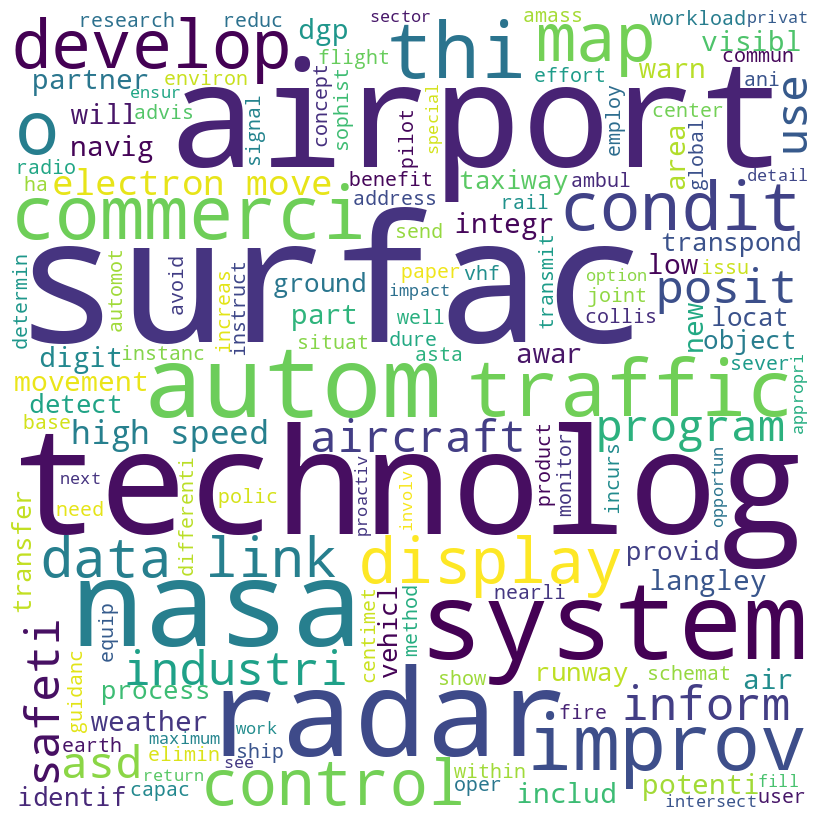

In [17]:
# join all the words into a single string separated by spaces
text = " ".join(docs_text_stemmed[0])

# create a WordCloud object
wordcloud = WordCloud(width=800, height=800, background_color="white", min_font_size=10, stopwords=None).generate(text)

# display the tag cloud
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)

plt.show()

### 3. Compute the <b><i>term frequency</i></b> $tf_{ij}$ and <b><i>tf-idf</i></b> $w_{ij}$ for each document with and without removing stop words.


*   With stopwords

In [18]:
docs_text_stemmed_str = [" ".join(doc) for doc in docs_text_stemmed]

# Compute TF
count_vectorizer = CountVectorizer()
tf_matrix = count_vectorizer.fit_transform(docs_text_stemmed_str)  # (num_docs × num_terms)
tf_df = pd.DataFrame(tf_matrix.toarray(), columns=count_vectorizer.get_feature_names_out())

# Compute TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(docs_text_stemmed_str)  # (num_docs × num_terms)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

p = 15  # Number of top stems per document (SEPARATELY)

# Extract top p stems for each document based on TF and TF-IDF
top_stems_per_doc = []

for i in range(len(docs_text_stemmed_str)):
    # Get top p stems based on TF for this document
    top_tf_stems = tf_df.iloc[i].nlargest(p).index.tolist()

    # Get top p stems based on TF-IDF for this document
    top_tfidf_stems = tfidf_df.iloc[i].nlargest(p).index.tolist()

    top_stems_per_doc.append({
        "Document": i,
        "Top TF Stems": top_tf_stems,
        "Top TF-IDF Stems": top_tfidf_stems
    })

top_stems_df = pd.DataFrame(top_stems_per_doc)

In [19]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

top_stems_df

,Document,Top TF Stems,Top TF-IDF Stems
0,0,"[the, and, surfac, to, of, airport, technolog, an, in, nasa, radar, system, autom, commerci, for]","[surfac, airport, the, radar, traffic, and, to, map, of, autom, improv, display, link, asd, technolog]"
1,1,"[the, of, match, cam, is, chip, to, in, that, data, technolog, bit, byte, and, commerci]","[the, match, cam, chip, bit, byte, of, memori, data, is, to, that, address, collabor, word]"
2,2,"[the, to, manipul, of, length, batten, truss, variabl, for, is, in, technolog, three, vgt, and]","[the, manipul, batten, truss, variabl, length, three, vgt, orient, plane, to, geometri, longeron, of, arm]"
3,3,"[and, the, in, for, system, cva, of, flow, bandwidth, high, make, to, with, anemomet, as]","[cva, and, flow, bandwidth, anemomet, voltag, the, in, constant, tao, larg, make, system, for, high]"
4,4,"[the, data, system, acquisit, and, to, of, commerci, for, is, softwar, thi, in, architectur, frequenc]","[acquisit, the, data, system, architectur, frequenc, open, softwar, medium, and, to, hardwar, support, proprietari, realtim]"
5,5,"[the, of, and, to, engin, piston, technolog, at, carboncarbon, ha, is, aluminum, temperatur, alloy, deg]","[piston, carboncarbon, engin, aluminum, the, of, alloy, deg, highperform, and, to, temperatur, output, at, becaus]"
6,6,"[the, gage, to, strain, of, temperatur, is, element, high, test, are, for, ha, at, in]","[gage, strain, the, temperatur, element, to, high, test, thermal, of, when, is, accuraci, appar, compens]"
7,7,"[the, and, of, to, system, weather, aircraft, commerci, for, is, by, data, epirep, air, are]","[the, and, weather, epirep, arnav, of, to, air, aviat, system, ga, increas, aircraft, billion, gdp]"
8,8,"[the, and, composit, technolog, for, develop, to, program, commerci, of, structur, act, nasa, is, materi]","[composit, the, and, act, structur, technolog, for, develop, to, offer, program, materi, cost, fabric, commerci]"
9,9,"[and, the, to, for, nasa, of, commerci, polyimid, coat, in, materi, technolog, transpar, applic, develop]","[polyimid, coat, and, the, transpar, dielectr, film, materi, to, for, nasa, of, colorless, commerci, low]"


In [20]:
def compute_tf(docs):
  count_vectorizer = CountVectorizer()
  tf_matrix = count_vectorizer.fit_transform(docs)  # (num_docs × num_terms)
  tf_df = pd.DataFrame(tf_matrix.toarray(), columns=count_vectorizer.get_feature_names_out())

  return count_vectorizer, tf_matrix, tf_df


def compute_tf_idf(docs):
  tfidf_vectorizer = TfidfVectorizer()
  tfidf_matrix = tfidf_vectorizer.fit_transform(docs_text_stemmed_str)  # (num_docs × num_terms)
  tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

  return tfidf_vectorizer, tfidf_matrix, tfidf_df


In [21]:
docs_text_stemmed_str = [" ".join(doc) for doc in docs_text_stemmed]

# TF
count_vectorizer, tf_matrix, tf_df = compute_tf(docs_text_stemmed_str)

# Compute TF-IDF
tfidf_vectorizer, tfidf_matrix, tfidf_df = compute_tf_idf(docs_text_stemmed_str)

# Select the top p stems based on their total term frequency across all documents
p = 15
top_p_stems = tf_df.sum(axis=0).nlargest(p).index.tolist()

# Extract only the top p stems from both TF and TF-IDF matrices
tf_top_p = tf_df[top_p_stems]
tfidf_top_p = tfidf_df[top_p_stems]

# Display the comparison
print("Top {} Stems Based on Term Frequency:".format(p))
print(tf_top_p)

print("\nTop {} Stems Based on TF-IDF:".format(p))
print(tfidf_top_p)


Top 15 Stems Based on Term Frequency:
    the  and  of  to  technolog  for  in  is  system  commerci  develop  nasa  thi  use  with
0    20   12  10  11          9    5   6   4       6         5        4     6    5    3     3
1    39    6  16  11          8    5   9  12       5         6        5     6    6    4     3
2    49    6  14  18          9   10   9  10       2         4        4     5    6    4     5
3    15   26   9   6          3   11  14   5      10         4        4     4    2    5     6
4    32   12   9  12          5    7   6   7      18         7        4     4    7    5     3
5    15   13  14  12          9    5   2   8       0         4        4     3    3    4     2
6    30    1  12  17          6    7   6  10       2         5        4     3    6    4     4
7    25   21  11  11          3    6   3   6       9         6        4     4    1    4     3
8    23   20   7  10         13   11   3   5       0         7       10     6    3    4     2
9    22   24  13  14  

In [22]:
tf_df

aaron  abil  abnorm  about  abov  absorpt  acceler  accept  accomplish  account  accur  \
0       0     0       0      0     0        0        0       0           0        0      0   
1       0     1       0      0     0        0        1       0           0        0      0   
2       0     0       0      0     0        0        0       0           2        0      0   
3       0     0       0      0     0        0        0       0           0        0      0   
4       0     0       0      0     0        0        0       0           0        0      0   
5       0     0       0      1     1        0        0       0           0        0      0   
6       0     0       0      0     0        0        0       0           0        0      0   
7       0     0       0      0     0        0        0       0           1        1      0   
8       0     0       0      0     0        0        0       0           0        0      0   
9       0     0       0      0     0        1        0       1           0        0      0   
10      0     0       0      1     0        0        0       0           0        0      0   
11      1     0       0      0     0        0        0       0           0        0      0   
12      0     2       3      0     0        0        0       1           0        0      0   
13      0     0       0      0     0        0        0       0           0        0      1   
14      0     2       0      0     0        0        0       0           0        0      0   

    accuraci  achiev  acquisit  act  activ  actual  actuat  ad  ada  adapt  add  addit  address  \
0          0       0         0    0      0       0       0   0    0      0    0      0        1   
1          0       0         0    0      2       0       0   1    0      0    0      0        4   
2          0       0         0    0      0       0       1   0    0      0    0      0        0   
3          0       0         0    0      1       0       0   0    0      0    0      1        0   
4          0       0        16    0      0       0       0   0    0      0    0      0        0   
5          0       2         0    0      0       0       0   0    0      0    0      0        0   
6          3       1         0    0      5       0       0   1    0      1    0      0        0   
7          0       0         0    0      2       0       0   0    0      0    1      1        0   
8          0       0         0    6      0       0       0   0    0      0    0      0        0   
9          0       0         0    0      0       0       0   0    0      0    0      0        0   
10         0       0         0    0      1       0       0   1    0      0    0      0        0   
11         0       0         0    0      0       0       0   0    1      0    0      2        0   
12         0       1         0    0      0       2       0   0    0      1    0      1        0   
13         0       0         0    0      0       0       0   0    0      0    0      0        0   
14         0       0         0    0      1       1       0   0    0      0    0      0        0   

    adjac  adjust  advanc  advantag  advis  aerial  aero  aerospac  afford  after  aftermarket  \
0       0       0       0         0      1       0     0         0       0      0            0   
1       0       0       0         0      0       0     0         0       0      0            0   
2       0       0       0         1      0       0     0         0       0      1            0   
3       0       3       1         0      0       0     0         0       0      0            0   
4       0       0       0         1      0       0     1         1       0      0            0   
5       0       0       1         1      0       0     0         0       0      0            0   
6       1       0       1         0      0       0     0         1       0      0            0   
7       0       0       1         0      0       0     0         0       1      0            1   
8       0       0       4       

*   Without stopwords

In [23]:
print([len(doc) for doc in docs_text_tokenized], end=' ')

[402, 511, 577, 497, 440, 429, 559, 448, 402, 529, 426, 552, 567, 353, 408] 

In [24]:
docs_text_tokenized = [[w for w in doc if w not in stop_words] for doc in docs_text_tokenized]

In [25]:
print([len(doc) for doc in docs_text_tokenized], end=' ')

[272, 308, 368, 356, 296, 288, 356, 307, 277, 363, 287, 351, 357, 234, 256] 

### Stemming

In [26]:
docs_text_stemmed = stem(docs_text_tokenized)

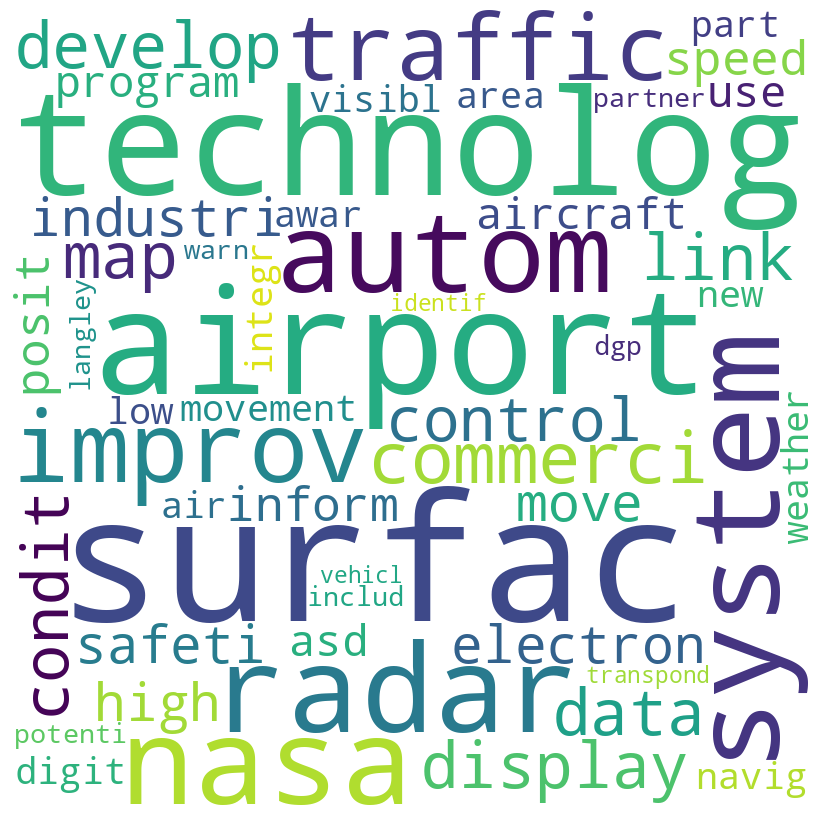

In [27]:
# join all the words into a single string separated by spaces
text = " ".join(docs_text_stemmed[0])

# count word frequencies
word_counts = Counter(text.split())

# get the top 50 most frequent words
top_50 = dict(word_counts.most_common(50))

# create a WordCloud object using only the top 50 words
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color="white",
    min_font_size=10,
    stopwords=None
).generate_from_frequencies(top_50)

# display the tag cloud
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)

# show the tag cloud
plt.show()

In [28]:
docs_text_stemmed_str = [" ".join(doc) for doc in docs_text_stemmed]

# Compute Term Frequency (TF)
count_vectorizer, tf_matrix, tf_df = compute_tf(docs_text_stemmed_str)

# Compute TF-IDF
tfidf_vectorizer, tfidf_matrix, tfidf_df = compute_tf_idf(docs_text_stemmed_str)

p = 15  # Number of top stems per document

# Extract top p stems for each document based on TF and TF-IDF
top_stems_per_doc = []

for i in range(len(docs_text_stemmed_str)):
    # Get top p stems based on TF for this document
    top_tf_stems = tf_df.iloc[i].nlargest(p).index.tolist()

    # Get top p stems based on TF-IDF for this document
    top_tfidf_stems = tfidf_df.iloc[i].nlargest(p).index.tolist()

    top_stems_per_doc.append({
        "Document": i,
        "Top TF Stems": top_tf_stems,
        "Top TF-IDF Stems": top_tfidf_stems
    })

# Convert to DataFrame for better visualization
top_stems_df = pd.DataFrame(top_stems_per_doc)

In [29]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

top_stems_df

,Document,Top TF Stems,Top TF-IDF Stems
0,0,"[surfac, airport, technolog, nasa, radar, system, autom, commerci, improv, traffic, condit, control, data, develop, display]","[surfac, airport, radar, traffic, map, autom, improv, display, link, asd, technolog, move, posit, speed, condit]"
1,1,"[match, cam, chip, data, technolog, bit, byte, commerci, nasa, design, develop, memori, system, address, applic]","[match, cam, chip, bit, byte, memori, data, address, collabor, word, version, technolog, intern, design, compar]"
2,2,"[manipul, length, batten, truss, variabl, technolog, three, vgt, orient, plane, two, applic, arm, cross, end]","[manipul, batten, truss, variabl, length, three, vgt, orient, plane, geometri, longeron, arm, cross, end, connect]"
3,3,"[system, cva, flow, bandwidth, high, make, anemomet, constant, larg, use, voltag, commerci, develop, dynam, flight]","[cva, flow, bandwidth, anemomet, voltag, constant, tao, larg, make, system, high, dynam, adjust, highspe, set]"
4,4,"[data, system, acquisit, commerci, softwar, architectur, frequenc, medium, open, technolog, use, develop, hardwar, nasa, support]","[acquisit, data, system, architectur, frequenc, open, softwar, medium, hardwar, support, proprietari, realtim, tunnel, wind, commerci]"
5,5,"[engin, piston, technolog, carboncarbon, aluminum, temperatur, alloy, deg, highperform, output, applic, commerci, develop, level, lower]","[piston, carboncarbon, engin, aluminum, alloy, deg, highperform, temperatur, output, fuelair, mixtur, technolog, lower, power, thermal]"
6,6,"[gage, strain, temperatur, element, high, test, technolog, thermal, activ, commerci, data, develop, use, accuraci, alloy]","[gage, strain, temperatur, element, high, test, thermal, accuraci, appar, compens, activ, alloy, instal, mechan, rate]"
7,7,"[system, weather, aircraft, commerci, data, epirep, air, arnav, aviat, develop, ga, gener, increas, nasa, product]","[weather, epirep, arnav, air, aviat, system, ga, increas, aircraft, billion, gdp, nation, upper, sensor, data]"
8,8,"[composit, technolog, develop, program, commerci, structur, act, nasa, materi, process, advanc, offer, use, autom, cost]","[composit, act, structur, technolog, develop, offer, program, materi, cost, fabric, commerci, advanc, durabl, previou, signific]"
9,9,"[nasa, commerci, polyimid, coat, materi, technolog, transpar, applic, develop, dielectr, low, film, thermal, colorless, electr]","[polyimid, coat, transpar, dielectr, film, materi, nasa, colorless, commerci, low, thermal, insul, electr, resist, flexibl]"


In [30]:
docs_text_stemmed_str = [" ".join(doc) for doc in docs_text_stemmed]

# Compute TF
count_vectorizer, tf_matrix, tf_df = compute_tf(docs_text_stemmed_str)

# Compute TF-IDF
tfidf_vectorizer, tfidf_matrix, tfidf_df = compute_tf_idf(docs_text_stemmed_str)

# Select the top p stems based on their total term frequency across all documents
p = 15
top_p_stems = tf_df.sum(axis=0).nlargest(p).index.tolist()

# Extract only the top p stems from both TF and TF-IDF matrices
tf_top_p = tf_df[top_p_stems]
tfidf_top_p = tfidf_df[top_p_stems]

print("Top {} Stems Based on Term Frequency:".format(p))
print(tf_top_p)

print("\nTop {} Stems Based on TF-IDF:".format(p))
print(tfidf_top_p)

Top 15 Stems Based on Term Frequency:
    technolog  system  commerci  develop  nasa  use  data  program  applic  softwar  materi  \
0           9       6         5        4     6    3     4        3       0        0       0   
1           8       5         6        5     6    4     8        3       4        0       0   
2           9       2         4        4     5    4     0        3       5        0       0   
3           3      10         4        4     4    5     0        2       3        0       0   
4           5      18         7        4     4    5    18        3       0        7       2   
5           9       0         4        4     3    4     0        3       4        0       1   
6           6       2         5        4     3    4     4        3       1        0       3   
7           3       9         6        4     4    4     5        3       0        0       0   
8          13       0         7       10     6    4     0        9       1        0       5   
9           

### 4. Build the <i>probabilistic</i> and <i>latent semantic indexing models</i> based on top $p$ stems according to <i>tf-idf</i> for each document, without removing stop words, and then provide $s$ queries to each IR system. Compare the rankings of the relevant articles for the two models.

In [31]:
from typing_extensions import final
from operator import index
class ProbModelIR:
    def __init__(self, root_docs_path, num_docs=15, p=50, remove_stop_words=False):
        self.root_docs_path = root_docs_path
        self.num_docs = num_docs
        self.p = p
        self.remove_stop_words = remove_stop_words

        # These will be initialized in termDocumentMatrixProbModel
        self.documents = None
        self.df = None  # Document frequencies
        self.P_t_given_R = None  # P(t_i|R)
        self.P_t_given_notR = None  # P(t_i|R̄)
        self.boolean_matrix = None  # Term-document matrix
        self.top_p_stems = None  # Top p index terms
        self.count_vectorizer = None  # For query transformation

    def termDocumentMatrixProbModel(self):
        # Find all files that end with .txt in the given directory and store them in a list
        self.documents = [file for file in os.listdir(self.root_docs_path) if file.endswith('txt')]

        # Limit to specified number of documents
        self.documents = self.documents[:self.num_docs]

        docs_text_raw = [None] * self.num_docs
        for num_file, file in enumerate(self.documents):
            with open(os.path.join(self.root_docs_path, file), mode='r', encoding='windows-1252') as f:
                docs_text_raw[num_file] = f.readlines()

        docs_text_tokenized = tokenize_docs(docs_text_raw)
        docs_text_tokenized = [flatten(doc) for doc in docs_text_tokenized]
        if self.remove_stop_words:
            docs_text_tokenized = [[w for w in doc if w not in stop_words] for doc in docs_text_tokenized]

        docs_text_stemmed = stem(docs_text_tokenized)
        # print(len(docs_text_stemmed)
        docs_text_stemmed_str = [" ".join(doc) for doc in docs_text_stemmed]
        # print(docs_text_stemmed_str)

        # TF
        _, _, tf_df = compute_tf(docs_text_stemmed_str)
        self.top_p_stems = tf_df.sum(axis=0).nlargest(self.p).index.tolist()
        # print(f"Top p stems: {self.top_p_stems}")

        # Create binary term-document matrix with only top p terms
        self.count_vectorizer = CountVectorizer(vocabulary=self.top_p_stems, binary=True)
        self.boolean_matrix = self.count_vectorizer.fit_transform(docs_text_stemmed_str).toarray()
        # print(self.boolean_matrix.shape)

        # Compute document frequencies for each term (nis)
        self.df = np.sum(self.boolean_matrix, axis=0)
        # print(self.df)

    def queryBooleanRepresentation(self, query):
        query = tokenize_docs([[query]])
        query = flatten(query)
        if self.remove_stop_words:
          query = [[w for w in doc if w not in stop_words] for doc in query]

        query = stem(query)
        query = query[0]
        # print(query)
        query_str = " ".join(query)

        # Transform query string into binary vector
        query_vector = self.count_vectorizer.transform([query_str])
        # print(query_vector.toarray())

        return query_vector.toarray()


    def similarity(self, boolean_matrix, query, P_t_given_R, P_t_given_notR):
      # Initialize similarity scores array
      scores = np.zeros(boolean_matrix.shape[0])

      query_vector = self.queryBooleanRepresentation(query)[0]

      # For each document
      for j in range(boolean_matrix.shape[0]):
          doc_vector = boolean_matrix[j]
          # print(f"Document vector: {j}: {doc_vector}")
          # print(doc_vector.shape)
          # print(query_vector.shape)

          # Initialize similarity score
          sim_score = 0

          # For each term (ti)
          for i in range(boolean_matrix.shape[1]):
                # Calculate term weights
                w_iq = query_vector[i]  # Binary weight for query term
                w_ij = doc_vector[i]  # Binary weight for document term

                p_t_r = P_t_given_R[i]
                # print(p_t_r)
                p_t_notr = P_t_given_notR[i]

                epsilon = 1e-10
                p_t_r = max(epsilon, min(1-epsilon, p_t_r))
                p_t_notr = max(epsilon, min(1-epsilon, p_t_notr))

                # Calculate the log components
                log_term1 = np.log(p_t_r / (1 - p_t_r))
                log_term2 = np.log((1 - p_t_notr) / p_t_notr)

                # Update similarity score
                sim_score += w_iq * w_ij * (log_term1 + log_term2)

          scores[j] = sim_score
          # print(scores)

      return scores



    def rankingProbModel(self, query, iterations=5, top_r=5):
      # Initial retrieval based on current probability estimates
      # Compute initial probabilities
      self.P_t_given_R = np.full(self.p, 0.5)
      self.P_t_given_notR = self.df / self.num_docs
      # print(self.P_t_given_notR)
      sim_scores = self.similarity(self.boolean_matrix, query, self.P_t_given_R, self.P_t_given_notR)
      # print(sim_scores)

      # Get top-r ranked documents
      ranked_indices = np.argsort(sim_scores)[::-1]  # Sort in descending order
      # print(ranked_indices)
      retrieved_docs = ranked_indices[:top_r]
      # print(retrieved_docs)
      # print(ranked_indices)

      # query_vector = self.queryBooleanRepresentation(query)[0]

      # Get corresponding filenames
      retrieved_filenames = [self.documents[idx] for idx in retrieved_docs]
      # num_terms = self.boolean_matrix.shape[1]
      # Iterative improvement
      for iteration in range(iterations):
          V = retrieved_docs
          # print(f"V: {V}")
          new_boolean_matrix = self.boolean_matrix[V, :]
          # print(f"new_boolean_matrix: {new_boolean_matrix}")
          # Create a mapping from original row index to new row index
          index_mapping = {new_idx: int(original_idx)  for new_idx, original_idx in enumerate(V)}
          # print(index_mapping)

          # print(new_boolean_matrix)
          new_df = np.sum(new_boolean_matrix, axis=0)
          # print(f"new_df: {new_df}")

          for term_index in range(self.p):
              # print(f"P_t_given_R: {self.P_t_given_R}")
              # print(f"P_t_given_notR: {self.P_t_given_notR}")
              num_relevant = new_df[term_index]
              # num_relevant = np.sum(new_boolean_matrix[:, V])

              self.P_t_given_R[term_index] = (num_relevant + 0.5) / (len(V) + 1)
              self.P_t_given_notR[term_index] = (self.df[term_index] - num_relevant + 0.5) / (self.num_docs - len(V) + 1)
              # print(self.df[term_index] - num_relevant)

          # print(f"P_t_given_R: {self.P_t_given_R}")
          # print(f"P_t_given_notR: {self.P_t_given_notR}")

          # Re-compute similarity scores with updated probabilities
          sim_scores = self.similarity(self.boolean_matrix[V, :], query, self.P_t_given_R, self.P_t_given_notR)
          # print(len(sim_scores))

          # # Re-rank documents
          ranked_indices = np.argsort(sim_scores)[::-1]
          retrieved_docs = ranked_indices[:top_r]
          retrieved_docs = [index_mapping[doc_id] for doc_id in retrieved_docs]

          # print(retrieved_docs)

      final_ranking = retrieved_docs
      final_filenames = [self.documents[idx] for idx in final_ranking]

      return final_ranking, final_filenames

In [62]:
class LSIModelIR:

    def __init__(self, root_docs_path, num_docs=15, p=50, remove_stop_words=False):
        self.root_docs_path = root_docs_path
        self.num_docs = num_docs
        self.p = p
        self.remove_stop_words = remove_stop_words

        # These will be initialized in termDocumentMatrixProbModel
        self.df = None  # Document frequencies
        self.td_matrix = None  # Term-document matrix
        self.top_p_stems = None  # Top p index terms
        self.count_vectorizer = None  # For query transformation


    def termDocumentMatrixLatentSemanticIndexing(self):
        # Find all files that end with .txt in the given directory and store them in a list
        self.documents = [file for file in os.listdir(self.root_docs_path) if file.endswith('txt')]
        # Limit to specified number of documents
        self.documents = self.documents[:self.num_docs]

        docs_text_raw = [None] * self.num_docs
        for num_file, file in enumerate(self.documents):
            with open(os.path.join(self.root_docs_path, file), mode='r', encoding='windows-1252') as f:
                docs_text_raw[num_file] = f.readlines()

        docs_text_tokenized = tokenize_docs(docs_text_raw)
        docs_text_tokenized = [flatten(doc) for doc in docs_text_tokenized]
        if self.remove_stop_words:
            docs_text_tokenized = [[w for w in doc if w not in stop_words] for doc in docs_text_tokenized]

        docs_text_stemmed = stem(docs_text_tokenized)
        # print(len(docs_text_stemmed))

        docs_text_stemmed_str = [" ".join(doc) for doc in docs_text_stemmed]
        # print(docs_text_stemmed_str)
        # print(len(docs_text_stemmed_str))

        # TF
        _, _, tf_df = compute_tf(docs_text_stemmed_str)

        # Select the top p stems based on their total term frequency across all documents
        self.top_p_stems = tf_df.sum(axis=0).nlargest(self.p).index.tolist()
        # print(f"Top p stems: {self.top_p_stems}")

        # Create term-document matrix with only top p terms
        self.count_vectorizer = CountVectorizer(vocabulary=self.top_p_stems)
        self.td_matrix = self.count_vectorizer.fit_transform(docs_text_stemmed_str).toarray()
        self.td_matrix = self.td_matrix.T
        # print(self.td_matrix.shape)

        # Compute document frequencies for each term
        self.df = np.sum(self.td_matrix, axis=0)  # Document frequencies
        # print(self.df)


    def queryVectorRepresentationLSIModel(self, query):
        query = tokenize_docs([[query]])
        query = flatten(query)
        if self.remove_stop_words:
          query = [[w for w in doc if w not in stop_words] for doc in query]

        query = stem(query)
        query = query[0]
        # print(query)
        query_str = " ".join(query)
        # Transform query string into binary vector
        query_vector = self.count_vectorizer.transform([query_str])
        # print(query_vector.toarray())

        return query_vector.toarray()


    def rankingLatentSemanticIndexing(self, query, l=10):
        query_vec = self.queryVectorRepresentationLSIModel(query)
        query_vec = query_vec.T
        # print(self.td_matrix.shape) ##(15, 50)
        # print(query_vec.shape)

        U, Sigma, V_T = np.linalg.svd(self.td_matrix, full_matrices=True)
        # print(U.shape) #(50, 50)
        # print(Sigma.shape) #(15,)
        # print(V_T.shape) #(15, 15)

        # Retain only the top l singular values
        Ul = U[:, :l]  # First l columns of S
        Sigmal = np.diag(Sigma[:l])  # Convert to diagonal matrix
        V_Tl = V_T[:l, :]  # First l rows of Dt
        # print(Ul.shape) #(50, 10)
        # print(Sigmal.shape) #(10, 10)
        # print(V_Tl.shape) #(10, 15)

        # Compute reduced term-document matrix
        # Wl = Ul @ Sigmal @ V_Tl
        # print(Wl.shape)

        Sigmal_inverse = np.linalg.inv(Sigmal)

        W_tilde = np.zeros((l, self.td_matrix.shape[1]))
        for j in range(self.td_matrix.shape[1]):
          dj = self.td_matrix[:, j]  # Get the j-th column of W
          d_tilde_j = Sigmal_inverse @ Ul.T @ dj
          # print(d_tilde_j.shape)
          W_tilde[:, j] = d_tilde_j

        # print(W_tilde.shape)

        q_tilde = Sigmal_inverse @ Ul.T @ query_vec
        # print(q_tilde.shape)

        # # Compute cosine similarity between W_q and each document in W_hat
        dot_products = np.dot(q_tilde.T, W_tilde)  # Compute dot products
        # print(dot_products)
        norms = np.linalg.norm(W_tilde, axis=0) * np.linalg.norm(q_tilde)  # Compute norms
        cosine_similarities = dot_products / (norms + 1e-10)  # Avoid division by zero
        # print(cosine_similarities[0][:5])

        # # Retrieve the top 6 documents
        top_indices = np.argsort(cosine_similarities[0])[::-1][:10]  # Sort in descending order
        # print(top_indices)

        final_filenames = [self.documents[idx] for idx in top_indices]
        return top_indices, final_filenames

In [63]:

# Initialize the LSI model
lsi_model = LSIModelIR(root_docs_path="nasa", num_docs=15, p=50, remove_stop_words=True)
lsi_model.termDocumentMatrixLatentSemanticIndexing()

# Define test queries
queries = ["engine",
           "analysis"
          ]

# Store results in a dataframe
data = []

for query in queries:
    lsi_ranked_indices, lsi_filenames = lsi_model.rankingLatentSemanticIndexing(query)

    data.append({
        "Query": query,
        "LSI Ranked Indices": lsi_ranked_indices,
        "LSI Ranked Filenames": lsi_filenames
    })

# Create DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
# print(df)
df


,Query,LSI Ranked Indices,LSI Ranked Filenames
0,engine,"[5, 12, 9, 11, 14, 6, 1, 4, 8, 2]","[str03295.txt, inf17195.txt, mat18195.txt, sbr17995.txt, mip14795.txt, eos19895.txt, inf17395.txt, inf18595.txt, str12695.txt, str01895.txt]"
1,analysis,"[11, 13, 9, 5, 1, 10, 2, 6, 4, 8]","[sbr17995.txt, emt04795.txt, mat18195.txt, str03295.txt, inf17395.txt, inf19695.txt, str01895.txt, eos19895.txt, inf18595.txt, str12695.txt]"


In [64]:
# df.to_csv('/content/drive/MyDrive/Colab Notebooks/nasa/ranking.csv', index=False)

# Save as JSON
df.to_json('/content/drive/MyDrive/Colab Notebooks/nasa/ranking.json', orient='records')


In [57]:

import pandas as pd

# Function to read relevance sets and extract filenames from paths
def read_relevance_set(file_path):
    with open(file_path, "r") as f:
        relevance_set = set(line.split(":")[0].split("/")[-1].replace(".key", ".txt") for line in f)
    return relevance_set

# Load relevance sets
engine_relevance = read_relevance_set("/content/drive/MyDrive/Colab Notebooks/nasa/engine_relevance.txt")
analysis_relevance = read_relevance_set("/content/drive/MyDrive/Colab Notebooks/nasa/analysis_relevance.txt")

# Generate binary lists
binary_lists = []

for index, row in df.iterrows():
    query = row["Query"]
    ranked_filenames = row["LSI Ranked Filenames"]

    # Select the appropriate relevance set
    if query == "engine":
        relevance_set = engine_relevance
    elif query == "analysis":
        relevance_set = analysis_relevance
    else:
        relevance_set = set()

    # Create binary list
    binary_list = [1 if filename in relevance_set else 0 for filename in ranked_filenames]
    binary_lists.append(binary_list)

# Add binary lists to the DataFrame
df["Binary List"] = binary_lists

# Display the DataFrame with the binary lists
df


,Query,LSI Ranked Indices,LSI Ranked Filenames,Binary List
0,engine,"[5, 12, 9, 11, 14, 6, 1, 4, 8, 2]","[str03295.txt, inf17195.txt, mat18195.txt, sbr17995.txt, mip14795.txt, eos19895.txt, inf17395.txt, inf18595.txt, str12695.txt, str01895.txt]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
1,analysis,"[11, 13, 9, 5, 1, 10, 2, 6, 4, 8]","[sbr17995.txt, emt04795.txt, mat18195.txt, str03295.txt, inf17395.txt, inf19695.txt, str01895.txt, eos19895.txt, inf18595.txt, str12695.txt]","[1, 0, 0, 0, 0, 1, 0, 0, 0, 0]"


In [33]:
# Initialize the probabilistic model
prob_model = ProbModelIR(root_docs_path="nasa", num_docs=15, p=50, remove_stop_words=False)
prob_model.termDocumentMatrixProbModel()

# Initialize the LSI model
lsi_model = LSIModelIR(root_docs_path="nasa", num_docs=15, p=50, remove_stop_words=False)
lsi_model.termDocumentMatrixLatentSemanticIndexing()

# Define test queries
queries = ['''
An inexpensive and simple means to improve control of helicopters has been
developed. During hovering flight in windy conditions, the pilot's ability
to maintain heading control is greatly enhanced by the addition of strakes
horizontally mounted along the helicopter tail boom. Without the strakes,
the tail boom "flies" in the winds from the main rotor and crosswinds which
causes the tail rotor to work harder and use up control available to the
pilot to maneuver the helicopter. The tail boom strakes act like a fence to
the airflow moving over the boom and changes the reactions of the boom in a
way to result in more control for the pilot and less power needed for the
tail rotor.''',
           '''It is now possible to obtain planar Rayleigh scattering data in Mach 6 flow
fields. This is due to the rapid technology advances in high power pulsed
excimer lasers, gated single intensified charge-couple device (CCD) cameras,
and fast frame grabbers. Because very short laser pulses (20 nanoseconds)
are used, the flow will be essentially frozen for each data acquisition
cycle. This allows snap-shots of the flow field to be taken. These
snap-shots can then reveal the extent of the unsteadiness in the flow field.
It is also possible to average these snap-shots and obtain a mean
quantitative density map of the flow field.''',
           '''Development of suspension devices for ground testing spacecraft has resulted
in the development of a small compact low stiffness support device. The
device can be designed to support weight of an object such that conditions
of weightlessness can be emulated at the point where an object is connected
to the device.''',
           '''kila cuubal mali la deukk aminta bakhoyo yokho''',


]

# Store results in a dataframe
data = []

for query in queries:
    prob_ranked_indices, prob_filenames = prob_model.rankingProbModel(query)
    lsi_ranked_indices, lsi_filenames = lsi_model.rankingLatentSemanticIndexing(query)

    data.append({
        "Query": query,
        "Probabilistic Ranked Indices": prob_ranked_indices,
        "Probabilistic Ranked Filenames": prob_filenames,
        "LSI Ranked Indices": lsi_ranked_indices,
        "LSI Ranked Filenames": lsi_filenames
    })

# Create DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
# print(df)
df


,Query,Probabilistic Ranked Indices,Probabilistic Ranked Filenames,LSI Ranked Indices,LSI Ranked Filenames
0,"\nAn inexpensive and simple means to improve control of helicopters has been\ndeveloped. During hovering flight in windy conditions, the pilot's ability\nto maintain heading control is greatly enhanced by the addition of strakes\nhorizontally mounted along the helicopter tail boom. Without the strakes,\nthe tail boom ""flies"" in the winds from the main rotor and crosswinds which\ncauses the tail rotor to work harder and use up control available to the\npilot to maneuver the helicopter. The tail boom strakes act like a fence to\nthe airflow moving over the boom and changes the reactions of the boom in a\nway to result in more control for the pilot and less power needed for the\ntail rotor.","[8, 11, 9, 14, 12]","[str12695.txt, sbr17995.txt, mat18195.txt, mip14795.txt, inf17195.txt]","[2, 7, 3, 13, 8]","[str01895.txt, sbr19195.txt, sbr12195.txt, emt04795.txt, str12695.txt]"
1,"It is now possible to obtain planar Rayleigh scattering data in Mach 6 flow\nfields. This is due to the rapid technology advances in high power pulsed\nexcimer lasers, gated single intensified charge-couple device (CCD) cameras,\nand fast frame grabbers. Because very short laser pulses (20 nanoseconds)\nare used, the flow will be essentially frozen for each data acquisition\ncycle. This allows snap-shots of the flow field to be taken. These\nsnap-shots can then reveal the extent of the unsteadiness in the flow field.\nIt is also possible to average these snap-shots and obtain a mean\nquantitative density map of the flow field.","[4, 0, 7, 3, 9]","[inf18595.txt, inf14495.txt, sbr19195.txt, sbr12195.txt, mat18195.txt]","[1, 2, 3, 7, 14]","[inf17395.txt, str01895.txt, sbr12195.txt, sbr19195.txt, mip14795.txt]"
2,Development of suspension devices for ground testing spacecraft has resulted\nin the development of a small compact low stiffness support device. The\ndevice can be designed to support weight of an object such that conditions\nof weightlessness can be emulated at the point where an object is connected\nto the device.,"[11, 4, 14, 10, 9]","[sbr17995.txt, inf18595.txt, mip14795.txt, inf19695.txt, mat18195.txt]","[1, 14, 11, 10, 0]","[inf17395.txt, mip14795.txt, sbr17995.txt, inf19695.txt, inf14495.txt]"
3,kila cuubal mali la deukk aminta bakhoyo yokho,"[10, 11, 12, 13, 14]","[inf19695.txt, sbr17995.txt, inf17195.txt, emt04795.txt, mip14795.txt]","[14, 13, 12, 11, 10]","[mip14795.txt, emt04795.txt, inf17195.txt, sbr17995.txt, inf19695.txt]"


### Compare the rankings of the relevant articles for the two models.
sjkhd

### 5. Remove the stop words and provide again the same queries to each IR model.

sdff

In [34]:
# Initialize the probabilistic model
prob_model = ProbModelIR(root_docs_path="nasa", num_docs=15, p=50, remove_stop_words=True)
prob_model.termDocumentMatrixProbModel()

# Initialize the LSI model
lsi_model = LSIModelIR(root_docs_path="nasa", num_docs=15, p=50, remove_stop_words=True)
lsi_model.termDocumentMatrixLatentSemanticIndexing()

# Define test queries
queries = ['''
An inexpensive and simple means to improve control of helicopters has been
developed. During hovering flight in windy conditions, the pilot's ability
to maintain heading control is greatly enhanced by the addition of strakes
horizontally mounted along the helicopter tail boom. Without the strakes,
the tail boom "flies" in the winds from the main rotor and crosswinds which
causes the tail rotor to work harder and use up control available to the
pilot to maneuver the helicopter. The tail boom strakes act like a fence to
the airflow moving over the boom and changes the reactions of the boom in a
way to result in more control for the pilot and less power needed for the
tail rotor.''',
           '''It is now possible to obtain planar Rayleigh scattering data in Mach 6 flow
fields. This is due to the rapid technology advances in high power pulsed
excimer lasers, gated single intensified charge-couple device (CCD) cameras,
and fast frame grabbers. Because very short laser pulses (20 nanoseconds)
are used, the flow will be essentially frozen for each data acquisition
cycle. This allows snap-shots of the flow field to be taken. These
snap-shots can then reveal the extent of the unsteadiness in the flow field.
It is also possible to average these snap-shots and obtain a mean
quantitative density map of the flow field.''',
           '''Development of suspension devices for ground testing spacecraft has resulted
in the development of a small compact low stiffness support device. The
device can be designed to support weight of an object such that conditions
of weightlessness can be emulated at the point where an object is connected
to the device.''',
           '''kila cuubal mali la deukk aminta bakhoyo yokho''',
           '''The project demands lightweight components, a high resolution real-time
video image and seamless integration with the magnetic crawler. Zoom
capabilities and a high resolution image will allow for highly detailed
video images while auto camera functions and a pan & tilt will allow for
versatility and easy operation. This combined technology offers a multitude
of remote inspection, sensing, mapping and access applications.''',


]

# Store results in a dataframe
data = []

for query in queries:
    prob_ranked_indices, prob_filenames = prob_model.rankingProbModel(query)
    lsi_ranked_indices, lsi_filenames = lsi_model.rankingLatentSemanticIndexing(query)

    data.append({
        "Query": query,
        "Probabilistic Ranked Indices": prob_ranked_indices,
        "Probabilistic Ranked Filenames": prob_filenames,
        "LSI Ranked Indices": lsi_ranked_indices,
        "LSI Ranked Filenames": lsi_filenames
    })

# Create DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
# print(df)
df


,Query,Probabilistic Ranked Indices,Probabilistic Ranked Filenames,LSI Ranked Indices,LSI Ranked Filenames
0,"\nAn inexpensive and simple means to improve control of helicopters has been\ndeveloped. During hovering flight in windy conditions, the pilot's ability\nto maintain heading control is greatly enhanced by the addition of strakes\nhorizontally mounted along the helicopter tail boom. Without the strakes,\nthe tail boom ""flies"" in the winds from the main rotor and crosswinds which\ncauses the tail rotor to work harder and use up control available to the\npilot to maneuver the helicopter. The tail boom strakes act like a fence to\nthe airflow moving over the boom and changes the reactions of the boom in a\nway to result in more control for the pilot and less power needed for the\ntail rotor.","[0, 9, 11, 12, 14]","[inf14495.txt, mat18195.txt, sbr17995.txt, inf17195.txt, mip14795.txt]","[12, 2, 0, 3, 14]","[inf17195.txt, str01895.txt, inf14495.txt, sbr12195.txt, mip14795.txt]"
1,"It is now possible to obtain planar Rayleigh scattering data in Mach 6 flow\nfields. This is due to the rapid technology advances in high power pulsed\nexcimer lasers, gated single intensified charge-couple device (CCD) cameras,\nand fast frame grabbers. Because very short laser pulses (20 nanoseconds)\nare used, the flow will be essentially frozen for each data acquisition\ncycle. This allows snap-shots of the flow field to be taken. These\nsnap-shots can then reveal the extent of the unsteadiness in the flow field.\nIt is also possible to average these snap-shots and obtain a mean\nquantitative density map of the flow field.","[4, 0, 6, 1, 12]","[inf18595.txt, inf14495.txt, eos19895.txt, inf17395.txt, inf17195.txt]","[4, 1, 8, 6, 12]","[inf18595.txt, inf17395.txt, str12695.txt, eos19895.txt, inf17195.txt]"
2,Development of suspension devices for ground testing spacecraft has resulted\nin the development of a small compact low stiffness support device. The\ndevice can be designed to support weight of an object such that conditions\nof weightlessness can be emulated at the point where an object is connected\nto the device.,"[4, 10, 13, 14, 11]","[inf18595.txt, inf19695.txt, emt04795.txt, mip14795.txt, sbr17995.txt]","[1, 14, 11, 8, 2]","[inf17395.txt, mip14795.txt, sbr17995.txt, str12695.txt, str01895.txt]"
3,kila cuubal mali la deukk aminta bakhoyo yokho,"[10, 11, 12, 13, 14]","[inf19695.txt, sbr17995.txt, inf17195.txt, emt04795.txt, mip14795.txt]","[14, 13, 12, 11, 10]","[mip14795.txt, emt04795.txt, inf17195.txt, sbr17995.txt, inf19695.txt]"
4,"The project demands lightweight components, a high resolution real-time\nvideo image and seamless integration with the magnetic crawler. Zoom\ncapabilities and a high resolution image will allow for highly detailed\nvideo images while auto camera functions and a pan & tilt will allow for\nversatility and easy operation. This combined technology offers a multitude\nof remote inspection, sensing, mapping and access applications.","[11, 7, 13, 4, 0]","[sbr17995.txt, sbr19195.txt, emt04795.txt, inf18595.txt, inf14495.txt]","[5, 12, 3, 10, 9]","[str03295.txt, inf17195.txt, sbr12195.txt, inf19695.txt, mat18195.txt]"


### Compare the current rankings of relevant articles with the ones obtained before.
dffd

### 6. Compare the BIR and LSI results with the results from the boolean and vector models in TP1 (with stop words removal).
sdhg

### 6. Compare the <i>BIR</i> and <i>LSI</i> results with the results from the <i>boolean</i> and <i>vector models</i> in TP1 (with stop words removal).

### 7. Final remarks and conclusions.